# Notebook 05 — Simulation

## Research Questions
1. **Q1 (Estimasi):** Berapa probabilitas sebuah PR di-merge, dan seberapa tidak pasti estimasi tersebut?
2. **Q2 (Inferensi):** Apakah rata-rata jumlah komentar berbeda secara signifikan antara PR yang merged vs unmerged?
3. **Q3 (Simulasi):** Berapa probabilitas sebuah issue butuh lebih dari 30 hari untuk ditutup? (Monte Carlo)

## Member
- **Nama:** Zaky Aditya Susanto
- **NIM :** 1519625023
- **Role:** Computation Analyst (Member E)

**Member:** Zaky Aditya Susanto - Computation Analyst (Member E)
 
**Tools used:** Chat GPT, Gemini

| Task | Tool | Prompt summary | Output modified? |
|---|---|---|---|
| Brainstorming pemilihan dan pengaplikasian metode simulasi | ChatGPT, Gemini | "Diberikan tiga pilihan metode, memilih metode yang paling tepat untuk Q3 berdasarkan pilihan tadi." | Yes — hanya mencari referensi dan pendalaman tugas |
| Mengeliminasi tada yang mengganggu | ChatGPT | "Gimana cara drop data yang masih open" | Yes — variabel disesuaikan walau template kode sama persis |

**Written entirely without AI:** Notebook markdowns, code variable and steps, pemilihan library, visualisasi. 

## IMPORT LIBRARY

- Library pandas digunakan untuk membaca data dan manipulasi data 
- Library random adalah library built-in python yang digunakan untuk memilih angka random untuk simulasi
- Library matplotlib digunakan untuk membuat chart sebagai instrumen visualisasi persebaran data

In [26]:
import pandas as pd
import random
import matplotlib.pyplot as plt


## READ DAN MANIPULASI DATA
1. definiskan data kedalam variabel 'df'
2. buang row yang masih berlabel "open" 
3. ubah tipe data waktu agar bisa di eskekusi

In [27]:
df = pd.read_csv("../data/clean/issues_clean.csv")
df = df.dropna(subset=["closed_at"])

df["created_at"] = pd.to_datetime(df["created_at"])
df["closed_at"] = pd.to_datetime(df["closed_at"])

df.head()

,number,title,state,created_at,closed_at,comments,author_association,state_reason,labels
1,65716,BUG: DataFrame.update warns when index dtype m...,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,0,NONE,NaN,[]
20,65697,"Revert ""BUG: reject unhashable elements in Ind...",closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,1,MEMBER,NaN,"[{'id': 1218227310, 'node_id': 'MDU6TGFiZWwxMj..."
22,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0,MEMBER,NaN,[]
26,65689,BUG: pyarrow-nightly CI fails during Pixi inst...,closed,2026-05-20 02:16:42+00:00,2026-05-20 03:58:29+00:00,0,CONTRIBUTOR,NaN,[]
28,65687,BLD: bump meson to 1.3.0,closed,2026-05-19 22:57:59+00:00,2026-05-20 00:30:11+00:00,1,MEMBER,NaN,[]


## MEMBUAT LIST JEDA WAKTU DARI OPEN KE CLOSE
1. buat kolom baru dengan value derivasi dari hasil pengurangan waktu akhir dengan waktu awal sehingga dihasilkan selisih waktu yang nanti akan digunakan untuk simulasi.
2. membuat list dari hasil kolom baru tadi agar bisa dioperasikan dengan metode dari library random

In [28]:
df["close_days"] = (df["closed_at"] - df["created_at"]).dt.days
df = df[df["close_days"] >= 0]
close_days = df["close_days"].tolist()

## SIMULASI
1. definisikan berapa kali simulasi dilakukan
2. buat variabel baru untuk menyimpan banyaknya data dengan nilai > 30
3. buat for loop sederhana dengan range jumlah simulasi. Simulasi dilakukan dengan memilih nilia acak dari list yang tadi sudah dibuat.
4. hitung probabilitas nilai akan sama dengan 30 dari banyaknya simulasi

NOTE : nilai simulasi dan hasil probabilitas pasti berubah ubah karna tidak menggunakan metode seed dari library numpy. 

In [29]:
num_simulations = 10000

count_over_30 = 0

for _ in range(num_simulations):

    sampled_day = random.choice(close_days)

    if sampled_day > 30:
        count_over_30 += 1

probability = count_over_30 / num_simulations

print("Estimated Probability:", probability)

Estimated Probability: 0.0721


## VISUALISASI HASIL

membuat visualisasi berupa diagram histogram dengan x adalah nilai waktu/hari dan y adalah frekuensinya. 
dapat dilihat bahwa berdasarkan 10,000 simulasi didapatkan paling banyak kisaran 0-1 hari. 

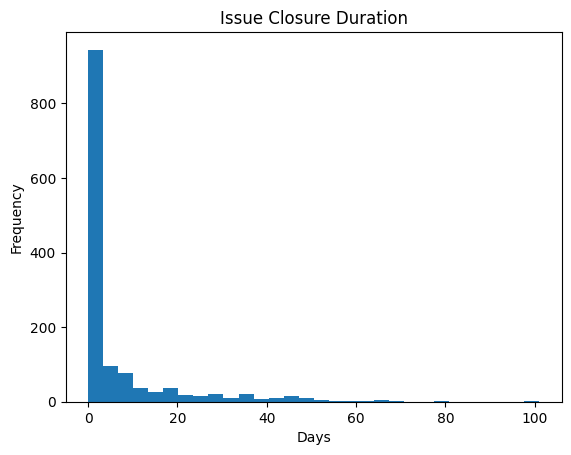

In [ ]:
plt.hist(df["close_days"], bins=30)

plt.title("Issue Closure Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()